## Load Mel Paths and Basic Setup

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
import random

mel_root = "/work/NLP-mini-project/datasets/fma/fma_clean/mels/"

# Collect mel file paths
mel_paths = []

for root, dirs, files in os.walk(mel_root):
    for f in files:
        if f.endswith(".npy"):
            mel_paths.append(os.path.join(root, f))

print("Found mel files:", len(mel_paths))

# Function to load shape only
def load_shape(path):
    mel = np.load(path, mmap_mode='r')   # zero-copy memory mapping
    return mel.shape

# Parallel load shapes
with Pool(processes=32) as p:
    mel_shapes = list(p.map(load_shape, mel_paths))

mel_shapes = np.array(mel_shapes)
time_lengths = mel_shapes[:, 1]
freq_bins = mel_shapes[:, 0]

print("Done. Shapes loaded.")

Found mel files: 90086
Done. Shapes loaded.


## Plot Random Mel Spectrograms for Visual Inspection

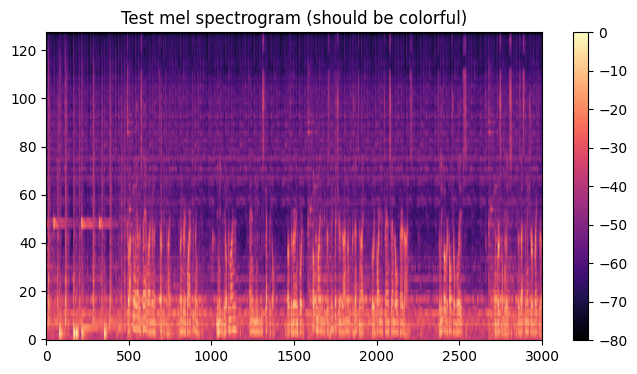

In [18]:
mel = np.load(random.choice(mel_paths))
plt.figure(figsize=(8,4))
plt.imshow(mel, aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.title("Test mel spectrogram")
plt.show()

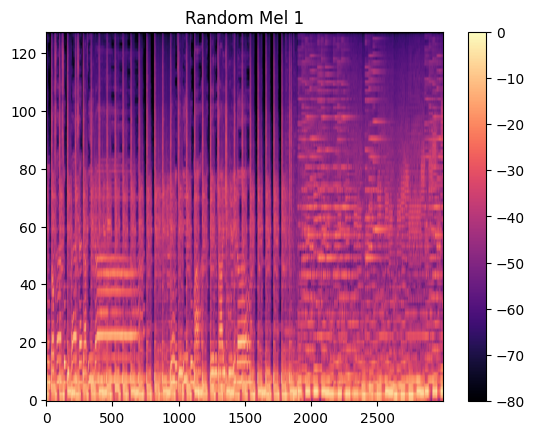

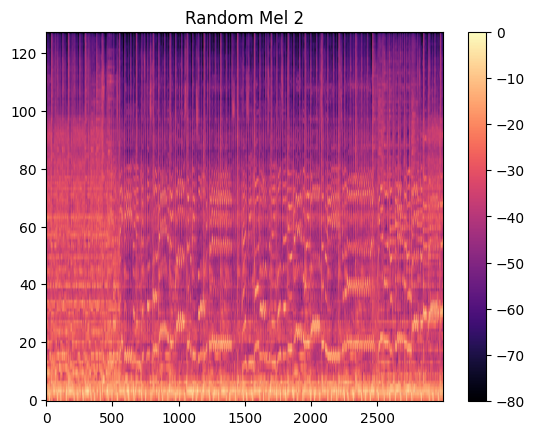

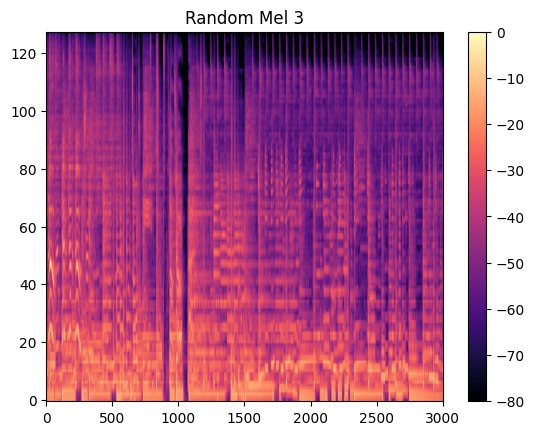

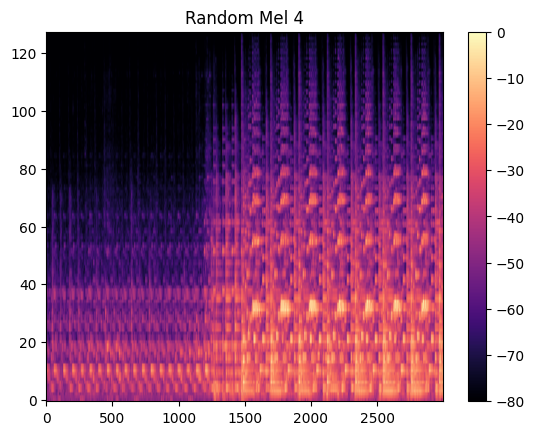

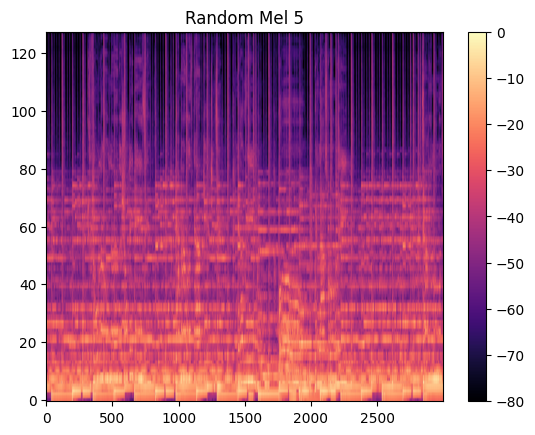

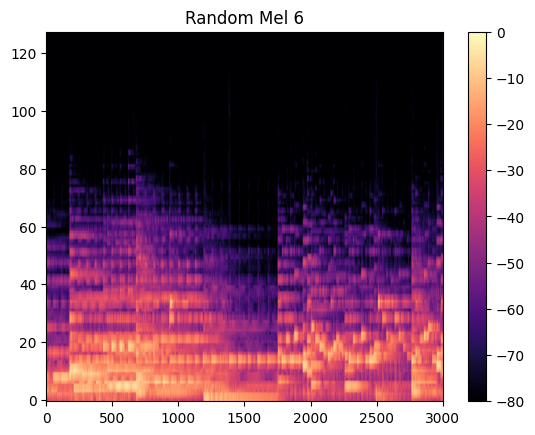

In [ ]:
# Visualize random mel spectrograms to inspect quality

for i in range(6):
    mel = np.load(random.choice(mel_paths))
    plt.imshow(mel, aspect='auto', origin='lower', cmap='magma')
    plt.title("Random Mel {}".format(i+1))
    plt.colorbar()
    plt.show()

## Inspect Value Range Of Random Mel

In [19]:
mel = np.load(random.choice(mel_paths))
print("Shape:", mel.shape)
print("Min:", mel.min())
print("Max:", mel.max())
print("Mean:", mel.mean())
print("Std:", mel.std())

Shape: (128, 3001)
Min: -80.0
Max: 0.0
Mean: -43.388706
Std: 11.379165


## Verify distribution across many samples

In [20]:
mins = []
maxs = []
means = []

for p in random.sample(mel_paths, 500):
    mel = np.load(p)
    mins.append(mel.min())
    maxs.append(mel.max())
    means.append(mel.mean())

print("Min(dB) stats: min =", min(mins), "max =", max(mins), "mean =", np.mean(mins))
print("Max(dB) stats: min =", min(maxs), "max =", max(maxs), "mean =", np.mean(maxs))
print("Mean(dB) stats: min =", min(means), "max =", max(means), "mean =", np.mean(means))

Min(dB) stats: min = -80.0 max = -78.27018 mean = -79.99456
Max(dB) stats: min = 0.0 max = 0.0 mean = 0.0
Mean(dB) stats: min = -68.58585 max = -24.919956 mean = -46.328133


## Inspect histogram of values (should match dB scale)

Long tail around -80 dB

Peak around -20 to -30 dB

Sharp cutoff near 0 dB

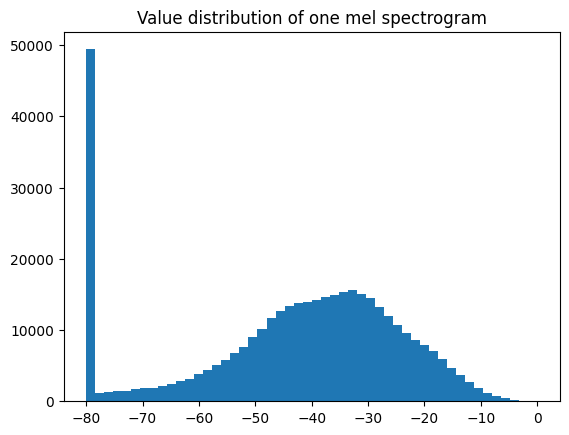

In [21]:
mel = np.load(random.choice(mel_paths))
plt.hist(mel.flatten(), bins=50)
plt.title("Value distribution of one mel spectrogram")
plt.show()

## Compute Mel Shapes (Frames + Frequency Bins)

In [ ]:
from multiprocessing import Pool

# Function to load only the shape of each mel file
def load_shape(path):
    mel = np.load(path, mmap_mode='r')  # mmap avoids full load to RAM
    return mel.shape

# Parallel processing of mel shapes
with Pool(processes=32) as p:   # adjust to available CPUs
    mel_shapes = p.map(load_shape, mel_paths)

mel_shapes = np.array(mel_shapes)

time_lengths = mel_shapes[:, 1]
freq_bins = mel_shapes[:, 0]

print("Unique frequency bin counts:", np.unique(freq_bins))
print("Time frame stats:")
print("Min:", time_lengths.min())
print("Max:", time_lengths.max())
print("Mean:", time_lengths.mean())
print("Std:", time_lengths.std())


Unique frequency bin counts: [128]
Time frame stats:
Min: 2952
Max: 3047
Mean: 2999.3012343760406
Std: 1.5941345751905498


## List All Time-Frame Lengths and Their Counts

In [ ]:
from collections import Counter

length_counts = Counter(time_lengths)

print("Frame length  ->  count")
print("--------------------------------")

for length in sorted(length_counts):
    print(f"{length:5d}        ->  {length_counts[length]}")

Frame length  ->  count
--------------------------------
 2952        ->  1
 2955        ->  2
 2958        ->  1
 2963        ->  1
 2966        ->  1
 2971        ->  1
 2973        ->  1
 2975        ->  1
 2978        ->  1
 2983        ->  1
 2984        ->  1
 2993        ->  1
 2995        ->  5
 2996        ->  6
 2997        ->  261
 2998        ->  48248
 2999        ->  3635
 3000        ->  174
 3001        ->  37712
 3002        ->  1
 3003        ->  2
 3005        ->  3
 3006        ->  2
 3007        ->  2
 3008        ->  2
 3015        ->  1
 3018        ->  1
 3019        ->  1
 3020        ->  1
 3023        ->  2
 3024        ->  1
 3026        ->  1
 3032        ->  1
 3033        ->  2
 3036        ->  1
 3038        ->  1
 3039        ->  1
 3040        ->  1
 3041        ->  3
 3042        ->  1
 3047        ->  1


## Plot Distribution of Mel Time Lengths

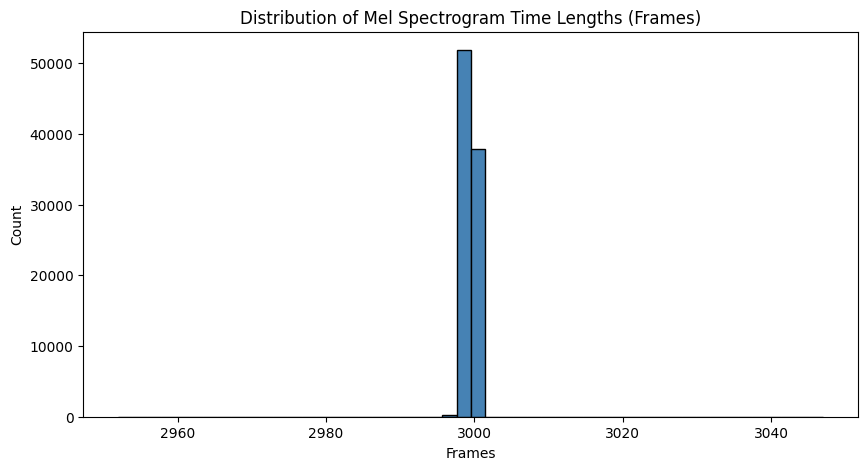

In [ ]:
# Histogram of time lengths of mel spectrograms
plt.figure(figsize=(10, 5))
plt.hist(time_lengths, bins=50, color="steelblue", edgecolor="black")
plt.title("Distribution of Mel Spectrogram Time Lengths (Frames)")
plt.xlabel("Frames")
plt.ylabel("Count")
plt.show()

## Compute Global Mean and Standard Deviation of All Mels

In [ ]:
# Compute global mean and std by reading all mels
# Useful for normalization during model training
import random
from multiprocessing import Pool

# Sample only N mel files (tune for speed)
N = 2000
sample_paths = random.sample(mel_paths, N)

def compute_stats(path):
    mel = np.load(path, mmap_mode='r')
    return mel.mean(), mel.std()

with Pool(processes=32) as p:
    stats = p.map(compute_stats, sample_paths)

means = np.array([s[0] for s in stats])
stds  = np.array([s[1] for s in stats])

print("Global mean (sample):", means.mean())
print("Global std  (sample):", stds.mean())


Global mean (sample): -46.73403
Global std  (sample): 16.061653


## Detect Potential Outlier Mels (Very Quiet or Empty)

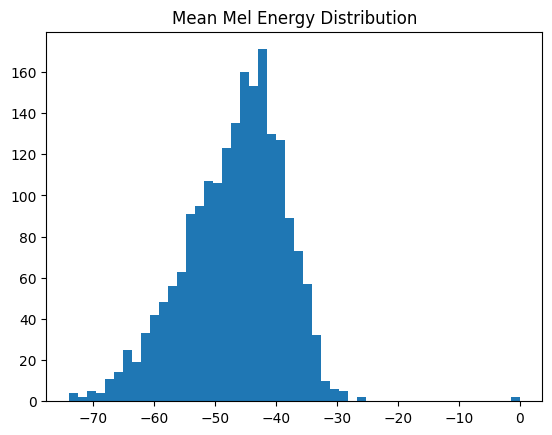

Possibly silent mels: 20


In [42]:
# Identify mels that have very low energy, possibly silent or corrupted

def compute_energy(path):
    mel = np.load(path, mmap_mode='r')
    return mel.mean()

with Pool(processes=32) as p:
    energies = p.map(compute_energy, sample_paths)  # sample 2k

energies = np.array(energies)

plt.hist(energies, bins=50)
plt.title("Mean Mel Energy Distribution")
plt.show()

threshold = np.percentile(energies, 1)
print("Possibly silent mels:", np.sum(energies < threshold))


## PCA on Flattened Mel Spectrograms (Structure Exploration)

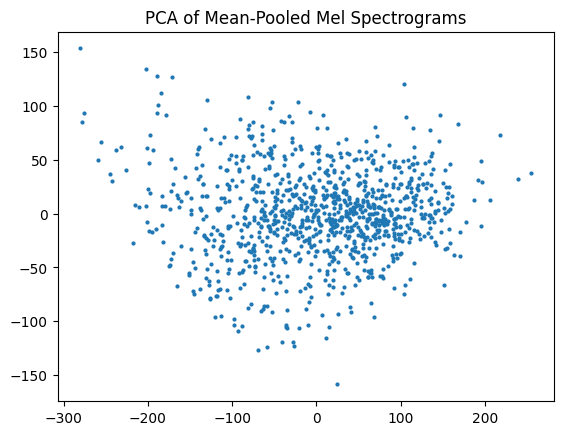

In [43]:
# PCA visualization to detect structure in mel embeddings

from sklearn.decomposition import PCA

K = 1000
sample_paths = random.sample(mel_paths, K)

X = []
for path in sample_paths:
    mel = np.load(path, mmap_mode='r')
    X.append(mel.mean(axis=1))

X = np.vstack(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], s=4)
plt.title("PCA of Mean-Pooled Mel Spectrograms")
plt.show()
